# Exploring EW4 data - GPM IMERG
This notebook explore the GPM IMERG dataset, including loading in PyEarthTools.

This dataset is a subset of the [NASA Integrated Multi-satellite Retrieval (IMERG)](https://gpm.nasa.gov/data/imerg) data for Global Precipitation Measurement (GPM). This subset has the following extents:
- Temporal Extent: April to September 2025
- Spatial Extent
  - Latitude 0N to 20N
  - Longitude 27W to 20E


### Import libraries

In [1]:
import pathlib
import datetime

In [2]:
import xarray

In [4]:
import matplotlib
import cartopy.crs

In [5]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/nopw/j04/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer'}


In [6]:
import pyearthtools

In [7]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe

In [8]:
from pyearthtools.data import Petdt, TimeDelta
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive


In [9]:
from site_archive_jasmin.utilities import (
    cached_exists,
    cached_iterdir,
)  # Could these be moved into a generic module?


## Explore the data in the dataset
Lets start by looking at a sample data file, before demonstrating loading the data in pyearthtools

In [10]:
ew4_gws_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')
imerg_ew4_dir = ew4_gws_dir / 'imerg_2025_summer'


In [11]:
def get_imerg_path(start_dt, time_delta, fname_template, data_dir):
    day_minutes = start_dt.hour * 60 + start_dt.minute
    date_str = '{dt.year:04d}{dt.month:02d}{dt.day:02d}'.format(dt=start_dt)
    time_template = '{dt.hour:02d}{dt.minute:02d}{dt.second:02d}'
    start_time = time_template.format(dt=start_dt)
    end_time = time_template.format(dt=start_dt+time_delta-datetime.timedelta(seconds=1))
    imerg_path = data_dir / fname_template.format(date_str=date_str,
                                              start_time=start_time,
                                              end_time=end_time,
                                                  day_minutes=day_minutes,
                                             )
    return imerg_path


In [12]:
imerg_fname_template = '3B-HHR-E.MS.MRG.3IMERG.{date_str}-S{start_time}-E{end_time}.{day_minutes:04d}.V07B.HDF5.SUB.nc4'

In [13]:
start_dt = datetime.datetime(2025,5,1,0,0)
end_dt = datetime.datetime(2025,6,1,0,0)
time_delta=datetime.timedelta(minutes=30)

In [14]:
num_files = int((end_dt - start_dt) / time_delta)

In [15]:
num_files

1488

In [16]:
imerg_filelist = [
    get_imerg_path(start_dt + (time_delta * time_ix),
                   time_delta,
                   imerg_fname_template,
                   imerg_ew4_dir
                  )
    for time_ix in range(num_files) ]


In [17]:
# ew4_imerge_sample_ds = xarray.open_mfdataset(imerg_filelist)

In [18]:
imerg_filelist[0]

PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')

In [19]:
# ew4_imerge_sample_ds.to_netcdf('/gws/nopw/j04/ew4energy/imerg_pet_tutorial/imerg_late_202505.nc')

In [20]:
# ew4_imerge_sample_ds['precipitation']


In [21]:
# float(min(ew4_imerge_sample_ds['lat'])), float(max(ew4_imerge_sample_ds['lat'])), float(min(ew4_imerge_sample_ds['lon'])), float(max(ew4_imerge_sample_ds['lon']))

In [22]:
precip_plot_bins = [1e-3,0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

In [23]:
# ew4_imerge_sample_ds['precipitation'].plot.hist(bins=precip_plot_bins)


In [24]:
# fig1 = matplotlib.pyplot.figure(figsize=(16,10))
# ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
# ew4_imerge_sample_ds['precipitation'][100].plot.contourf(ax=ax1)
# ax1.coastlines(color='w')

## Loading the Data in PyEarthTools
Now we will load the data through the PyEarthTools data accessor. This is a class that has been created which how to access the data. For a dataset like this which is stored as files on disk, it specifries which files to load. Data could be loaded through other mechanisms though, for example it could be load from a database, through a web api, from a tape archive,  from a cloud-based object store or many other mechanisms.

In [25]:
ew4_imerg_accessor = site_archive_jasmin.Ew4Imerg('2025-04-01 00:00', '2025-10-01 00:00')

2025-04-01 00:00
2025-10-01 00:00


In [26]:
ew4_imerg_accessor

Ew4Imerg
	Description                    GPM IMERG - EW4Energy project 
		 range                          '2025-04-01 to 2025-09-30'
		 Documentation                  'https://gpm.nasa.gov/data/imerg'


	Initialisation                 
		 end                            '2025-10-01 00:00'
		 start                          '2025-04-01 00:00'
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [27]:
ew4_imerg_accessor['2025-05-23 03:00']

2025-05-23T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250523-S030000-E032959.0180.V07B.HDF5.SUB.nc4')]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T03:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [28]:
ew4_imerg_accessor['2025-05-23 13']



2025-05-23T13
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250523-S130000-E132959.0780.V07B.HDF5.SUB.nc4')]


<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T13:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

2025-05-23T03
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250523-S033000-E035959.0210.V07B.HDF5.SUB.nc4')]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


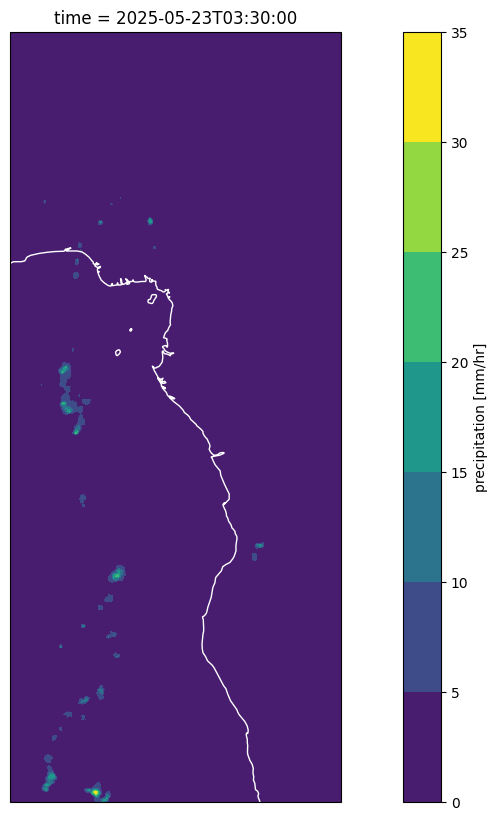

In [29]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_imerg_accessor['2025-05-23 03:30']['precipitation'][0].plot.contourf(ax=ax1)

ax1.coastlines(color='w')


In [30]:
ghana_extents = {
    'latitude': (4.5,11.25),
    'longitude': (-3.5, 1.5),
}


In [31]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['longitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][1],
                )

In [32]:
help(petpipe.modifications.TemporalWindow)

Help on class TemporalWindow in module pyearthtools.pipeline.modifications.idx_modification:

class TemporalWindow(pyearthtools.pipeline.controller.PipelineIndex)
 |  TemporalWindow(*, prior_indexes, posterior_indexes, timedelta, merge_method=None)
 |
 |  The purpose of this class is to provide the ability to perform
 |  sequence-to-sequence modelling from a data accessor or pipeline
 |  that was designed to produce single time steps (i.e. single samples).
 |
 |  The temporal window allows the specification of the 'back window'
 |  and the 'forward window', and will produce a binary branch.
 |
 |  For example, if the time steps are hourly, and the base pipeline
 |  can produce hours 1, 2, 3 ... 10; then this Temporal Window can
 |  be used to produce sequence pairs like::
 |
 |       [1,2,3], [4],
 |       [2,3,4], [5],
 |       ...
 |       [7,8,9], [10]
 |
 |  or like::
 |
 |       [1,2], [3,4,5],
 |       [2,3], [4,5,6],
 |       ...
 |       [6,7], [8,9,10]
 |
 |  This provides a s

In [33]:
# todo update timedelta constructor to take a string or datetime.TimeDelta
# add nc4 extension


In [34]:
ew4_imerg_pipeline = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),  
    petpipe.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('30 minutes')),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250511T00', interval='4 hours'), 
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


In [35]:
ew4_imerg_pipeline['20250503T0700']

2025-05-03T07
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250503-S070000-E072959.0420.V07B.HDF5.SUB.nc4')]
2025-05-03T07
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250503-S070000-E072959.0420.V07B.HDF5.SUB.nc4')]


/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


([<xarray.Dataset> Size: 18kB
  Dimensions:        (time: 1, longitude: 98, latitude: 45)
  Coordinates:
    * time           (time) datetime64[ns] 8B 2025-05-03T07:00:00
    * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
    * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
  Data variables:
      precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
  Attributes:
      CDI:                                    Climate Data Interface version 1....
      Conventions:                            CF-1.6
      Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
      Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
      Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
      InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250503-S...
      history_L34RS:                          'Created

In [36]:
next(iter(ew4_imerg_pipeline))

2025-05-01T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]
2025-05-01T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]


([<xarray.Dataset> Size: 18kB
  Dimensions:        (time: 1, longitude: 98, latitude: 45)
  Coordinates:
    * time           (time) datetime64[ns] 8B 2025-05-01
    * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
    * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
  Data variables:
      precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
  Attributes:
      CDI:                                    Climate Data Interface version 1....
      Conventions:                            CF-1.6
      Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
      Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
      Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
      InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
      history_L34RS:                          'Created by L34RS

In [37]:
ew4_imerg_iter = iter(ew4_imerg_pipeline)

In [38]:
next(ew4_imerg_iter), 

2025-05-01T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]
2025-05-01T00
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4')]


(([<xarray.Dataset> Size: 18kB
   Dimensions:        (time: 1, longitude: 98, latitude: 45)
   Coordinates:
     * time           (time) datetime64[ns] 8B 2025-05-01
     * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
     * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
   Data variables:
       precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
   Attributes:
       CDI:                                    Climate Data Interface version 1....
       Conventions:                            CF-1.6
       Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
       Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
       Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
       InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
       history_L34RS:                          '

In [39]:
next(ew4_imerg_iter), 

2025-05-01T04
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S040000-E042959.0240.V07B.HDF5.SUB.nc4')]
2025-05-01T04
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S040000-E042959.0240.V07B.HDF5.SUB.nc4')]


(([<xarray.Dataset> Size: 18kB
   Dimensions:        (time: 1, longitude: 98, latitude: 45)
   Coordinates:
     * time           (time) datetime64[ns] 8B 2025-05-01T04:00:00
     * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
     * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
   Data variables:
       precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
   Attributes:
       CDI:                                    Climate Data Interface version 1....
       Conventions:                            CF-1.6
       Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
       Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
       Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
       InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
       history_L34RS:                  

In [40]:
next(ew4_imerg_iter), next(ew4_imerg_iter),

2025-05-01T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-05-01T08
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S080000-E082959.0480.V07B.HDF5.SUB.nc4')]
2025-05-01T12
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S120000-E122959.0720.V07B.HDF5.SUB.nc4')]
2025-05-01T12
[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S120000-E122959.0720.V07B.HDF5.SUB.nc4')]


(([<xarray.Dataset> Size: 18kB
   Dimensions:        (time: 1, longitude: 98, latitude: 45)
   Coordinates:
     * time           (time) datetime64[ns] 8B 2025-05-01T08:00:00
     * longitude      (longitude) float32 392B 1.55 1.65 1.75 ... 11.05 11.15 11.25
     * latitude       (latitude) float32 180B 0.05 0.15 0.25 ... 4.25 4.35 4.45
   Data variables:
       precipitation  (time, longitude, latitude) float32 18kB dask.array<chunksize=(1, 98, 45), meta=np.ndarray>
   Attributes:
       CDI:                                    Climate Data Interface version 1....
       Conventions:                            CF-1.6
       Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
       Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
       Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
       InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
       history_L34RS:                  

In [ ]:
#todo
# - find start and end time for data and select 1 day
# get all files
# load into dataset
# create a PET accessor to load those files
# demonstrate visualising
# create a demo autoencoder for the data
